In [11]:
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import rasterio
from matplotlib import pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    f1_score,
)

from estuary.util.img import false_color

In [31]:
SAVE_DIR = Path("/Users/kyledorman/data/estuary/display/paper_figures")
SAVE_DIR.mkdir(exist_ok=True, parents=True)

In [12]:
def inspect_row(iii, suffix_t, suffix_p):
    _, row = next(iii)

    with rasterio.open(row[f"source_tif{suffix_t}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        t = false_color(data, nodata)

    with rasterio.open(row[f"source_tif{suffix_p}"]) as src:
        data = src.read()
        nodata = src.read(1, masked=True).mask
        p = false_color(data, nodata)

    label_t = row[f"label{suffix_t}"]
    label_p = row[f"label{suffix_p}"]

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].set_title(f"Region {row.region} True Label: {label_t}")
    axes[1].set_title(f"Pred Label: {label_p}")

    axes[0].imshow(t)
    axes[0].axis("off")
    axes[1].imshow(p)
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()

In [13]:
BASE = Path("/Volumes/x10pro/estuary/")

In [14]:
gdf = gpd.read_file(BASE / "geos/ca_data_w_empa_pmep_usgs.geojson")
gdf = gdf[~gdf.skipped].copy()
gdf = gdf.set_index("Site code")
gdf.head(3)

,Site name,skipped,PMEP_EstuaryID,Estuary_Name,Data_Source,CMECS_Class,PMEP_Region,System_Order,Estuary_Hectares,Link,...,siteid,point_geom_lat,point_geom_long,pmep_pt_geom_lat,pmep_pt_geom_long,usgs_station_nm,usgs_site_no,usgs_site_latitude,usgs_site_longitude,geometry
Site code,,,,,,,,,,,,,,,,,,,,,
11,Los Penasquitos Lagoon,False,4056.0,Los Penasquitos Lagoon,PMEP,Lagoonal Estuary,Southern California Bight,299.0,95.475975,4056_Los Penasquitos Lagoon,...,SC-LPL,32.933,-117.260,32.931536,-117.256714,None,None,None,None,"POLYGON ((-117.25816 32.93218, -117.25817 32.9..."
18,Zuma Lagoon,False,4018.0,Zuma Canyon,PMEP,Lagoonal Estuary,Southern California Bight,262.0,1.779315,4018_Zuma Canyon,...,SC-ZUM,34.015,-118.821,34.014565,-118.820618,None,None,None,None,"POLYGON ((-118.81685 34.01177, -118.81699 34.0..."
21,Ventura River,False,4010.0,Ventura River,PMEP,Lagoonal Estuary,Southern California Bight,253.0,17.225009,4010_Ventura River,...,SC-VEN,34.276,-119.308,34.277309,-119.308329,None,None,None,None,"POLYGON ((-119.30473 34.27203, -119.3049 34.27..."


In [15]:
ss_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat/labels.csv")
ss_df = ss_df[ss_df.region.isin(gdf.index)].copy()
ss_df = ss_df[ss_df.label != "unsure"].copy()
ss_df["acquired"] = pd.to_datetime(ss_df["acquired"], errors="coerce", utc=True)

ssw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/skysat_water/labels.csv")
ssw_df = ssw_df[ssw_df.region.isin(gdf.index)].copy()
ssw_df = ssw_df[ssw_df.label != "unsure"].copy()
ssw_df["acquired"] = pd.to_datetime(ssw_df["acquired"], errors="coerce", utc=True)

ss_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-20 17:07:34+00:00,skysat,2024,10,20241020_170734_ssc13_u0001
1,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-21 16:24:30+00:00,skysat,2024,10,20241021_162430_ssc4_u0001
2,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
3,15,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001
4,16,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2024-10-22 17:19:42+00:00,skysat,2024,10,20241022_171942_ssc1_u0001


In [16]:
d_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_split_by_region/labels.csv")
d_df = d_df[d_df.region.isin(gdf.index)].copy()
d_df = d_df[d_df.label != "unsure"].copy()
d_df["acquired"] = pd.to_datetime(d_df["acquired"], errors="coerce", utc=True)

dw_df = pd.read_csv("/Volumes/x10pro/estuary/labeling/dove_water/labels.csv")
dw_df = dw_df[dw_df.region.isin(gdf.index)].copy()
dw_df = dw_df[dw_df.label != "unsure"].copy()
dw_df["acquired"] = pd.to_datetime(dw_df["acquired"], errors="coerce", utc=True)

d_df.head()

,region,source_tif,label,acquired,instrument,year,month,asset_id
0,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,open,2017-01-28 17:55:35+00:00,dove,2017,1,20170128_175535_0e26
1,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,perched open,2017-02-13 17:57:19+00:00,dove,2017,2,20170213_175719_0e0f
2,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-04-15 17:50:47+00:00,dove,2017,4,20170415_175047_1009
3,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-05-08 17:52:59+00:00,dove,2017,5,20170508_175259_0f25
4,22,/Volumes/x10pro/estuary/sat_data/dove/results/...,closed,2017-06-14 17:54:49+00:00,dove,2017,6,20170614_175449_0f52


In [17]:
ss_pairs = pd.merge(
    ss_df, ssw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)
dd_pairs = pd.merge(
    d_df, dw_df, on=["region", "asset_id"], how="inner", suffixes=("_img", "_water")
)

a = ss_df.sort_values("acquired").reset_index(drop=True)
b = d_df.sort_values("acquired").reset_index(drop=True)

# cross-join within region, then filter by window
tmp = pd.merge(
    a,
    b[["source_tif", "asset_id", "region", "label", "acquired"]],
    on="region",
    suffixes=("_ss", "_dd"),
)
tol = pd.Timedelta("10h")
tmp["time_diff"] = (tmp["acquired_dd"] - tmp["acquired_ss"]).abs()
mask = tmp["time_diff"] < tol
d_ss_pairs = tmp.loc[mask].sort_values(["region", "asset_id_ss", "asset_id_dd"])
d_ss_pairs = d_ss_pairs.drop_duplicates(["region", "asset_id_ss"])

len(d_ss_pairs)

477

In [18]:
d_ss_pairs.head()

,region,source_tif_ss,label_ss,acquired_ss,instrument,year,month,asset_id_ss,source_tif_dd,asset_id_dd,label_dd,acquired_dd,time_diff
30474,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2020-08-01 18:45:36+00:00,skysat,2020,8,20200801_184536_ssc1_u0002,/Volumes/x10pro/estuary/sat_data/dove/results/...,20200801_161237_0f2e,open,2020-08-01 16:12:37+00:00,0 days 02:32:59
55911,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2021-11-10 21:35:51+00:00,skysat,2021,11,20211110_213551_ssc6_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20211110_175344_57_227e,open,2021-11-10 17:53:44+00:00,0 days 03:42:07
72891,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2022-06-24 01:30:52+00:00,skysat,2022,6,20220624_013052_ssc18_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20220623_180838_89_2478,open,2022-06-23 18:08:38+00:00,0 days 07:22:14
100710,11,/Volumes/x10pro/estuary/sat_data/skysat/result...,open,2023-06-29 21:52:17+00:00,skysat,2023,6,20230629_215217_ssc6_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20230629_173907_70_24c3,open,2023-06-29 17:39:07+00:00,0 days 04:13:10
58893,14,/Volumes/x10pro/estuary/sat_data/skysat/result...,closed,2021-12-15 18:44:53+00:00,skysat,2021,12,20211215_184453_ssc1_u0001,/Volumes/x10pro/estuary/sat_data/superdove/res...,20211215_182546_45_2424,closed,2021-12-15 18:25:46+00:00,0 days 00:19:07


In [19]:
d_ss_pairs.label_ss.value_counts()

label_ss
closed          233
open            203
perched open     41
Name: count, dtype: int64

Accuracy 3 class 77.6
Perched F1 44.2


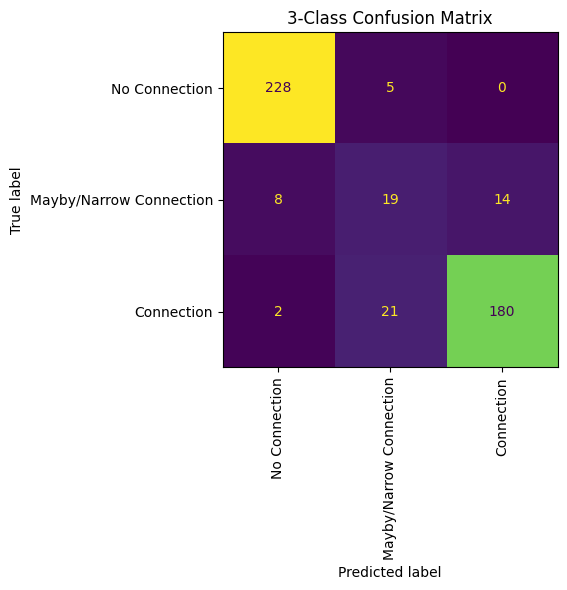

Accuracy Open/Closed 96.9


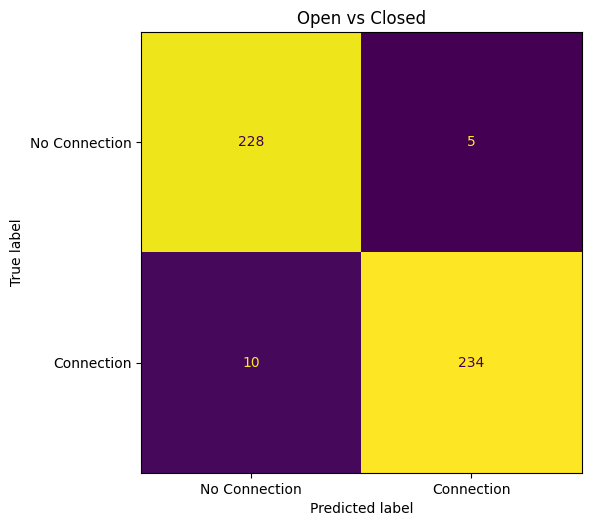

Accuracy No Perch 99.5


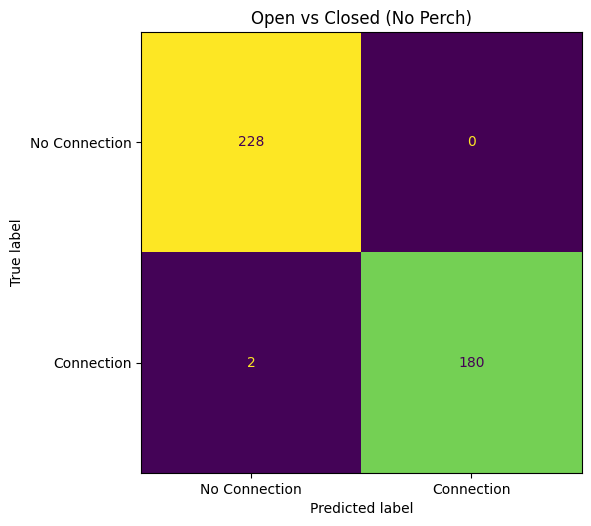

In [41]:
labels = ["closed", "perched open", "open"]
disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
y_true = np.array([labels.index(l) for l in d_ss_pairs.label_ss])
y_pred = np.array([labels.index(l) for l in d_ss_pairs.label_dd])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
    xticks_rotation="vertical",
)

ax.set_title("3-Class Confusion Matrix")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_3class_dove_ss.png", dpi=300)
plt.show()

labels = ["closed", "open"]
disp_labels = ["No Connection", "Connection"]
y_true = [int("open" in l) for l in d_ss_pairs.label_ss]
y_pred = [int("open" in l) for l in d_ss_pairs.label_dd]

print("Accuracy Open/Closed", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Open vs Closed")

fig.tight_layout()
fig.savefig("cm_open_closed_dove_ss.png", dpi=300)
plt.show()

y_true = [
    int("open" in l)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]
y_pred = [
    int("open" in p)
    for l, p in zip(d_ss_pairs.label_ss, d_ss_pairs.label_dd)
    if "perch" not in l and "perch" not in p
]

print("Accuracy No Perch", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Connection vs Not (No Perch)")

fig.tight_layout()
fig.savefig("cm_no_perch_dove_ss.png", dpi=300)
plt.show()

In [21]:
# inspect = pd.concat([
#     d_ss_pairs[(d_ss_pairs.label_ss == "closed") & (d_ss_pairs.label_dd == "open")],
#     d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
# ])
inspect = d_ss_pairs[(d_ss_pairs.label_ss == "open") & (d_ss_pairs.label_dd == "closed")]
inspect_iter = inspect.iterrows()

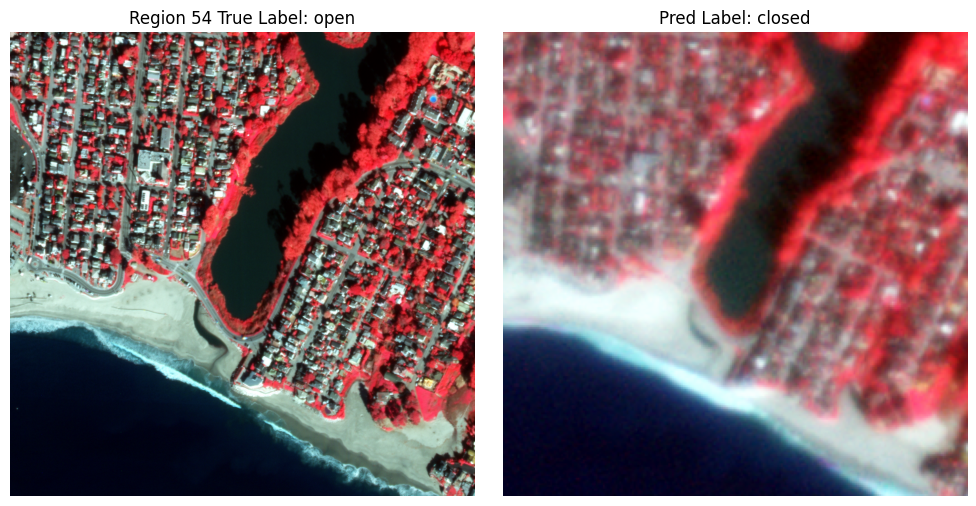

In [22]:
inspect_row(inspect_iter, "_ss", "_dd")

In [23]:
dd_pairs.label_water.value_counts()

label_water
closed          537
open            515
perched open     70
Name: count, dtype: int64

In [39]:
dd_pairs.columns

Index(['region', 'source_tif_img', 'label_img', 'acquired_img',
       'instrument_img', 'year_img', 'month_img', 'asset_id',
       'source_tif_water', 'label_water', 'acquired_water', 'instrument_water',
       'year_water', 'month_water'],
      dtype='object')

Accuracy 3 class 82.0
Perched F1 59.1


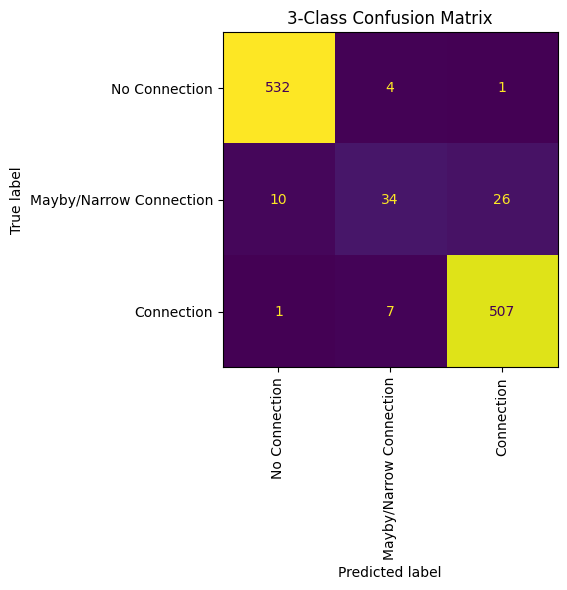

Accuracy Connection (Maybe as connection) 98.6


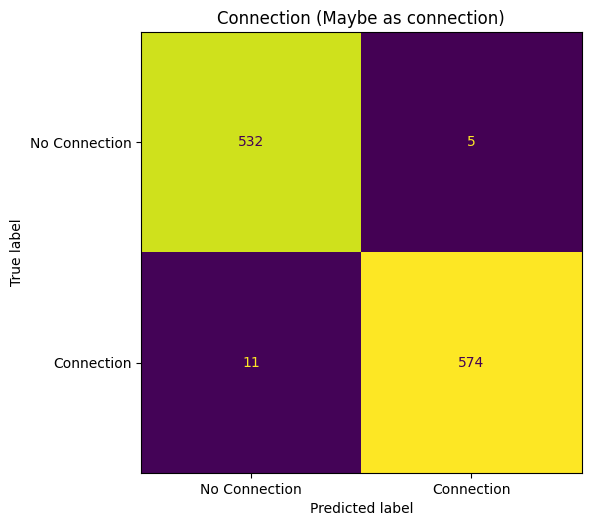

Connection (Maybe as connection) 99.8


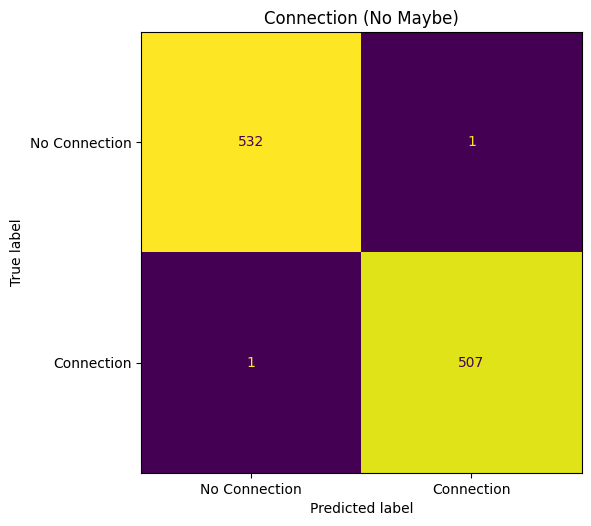

In [54]:
labels = ["closed", "perched open", "open"]
disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
y_true = np.array([labels.index(l) for l in dd_pairs.label_water])
y_pred = np.array([labels.index(l) for l in dd_pairs.label_img])

print("Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
    xticks_rotation="vertical",
)

ax.set_title("3-Class Confusion Matrix")

fig.tight_layout()
fig.savefig(SAVE_DIR / "cm_3class_dove_water.png", dpi=300)
plt.show()

labels = ["closed", "open"]
disp_labels = ["No Connection", "Connection"]
y_true = [int("open" in l) for l in dd_pairs.label_water]
y_pred = [int("open" in l) for l in dd_pairs.label_img]

print(
    "Accuracy Connection (Maybe as connection)",
    round(100 * balanced_accuracy_score(y_true, y_pred), 1),
)

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Connection (Maybe as connection)")

fig.tight_layout()
fig.savefig("cm_open_closed_dove_water.png", dpi=300)
plt.show()

y_true = [
    int("open" in l)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in l and "perch" not in p
]
y_pred = [
    int("open" in p)
    for l, p in zip(dd_pairs.label_water, dd_pairs.label_img)
    if "perch" not in l and "perch" not in p
]

print("Connection (Maybe as connection)", round(100 * balanced_accuracy_score(y_true, y_pred), 1))

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=ax,
    colorbar=False,
)

ax.set_title("Connection (No Maybe)")

fig.tight_layout()
fig.savefig("cm_no_perch_dove_water.png", dpi=300)
plt.show()

In [25]:
# inspect_d = pd.concat(
#     [
#         dd_pairs[(dd_pairs.label_water == "closed") & (dd_pairs.label_img == "open")],
#         dd_pairs[(dd_pairs.label_water == "open") & (dd_pairs.label_img == "closed")],
#     ]
# )
inspect_d = dd_pairs[(dd_pairs.label_water == "perched open") & (dd_pairs.label_img == "closed")]
inspect_d_iter = inspect_d.iterrows()

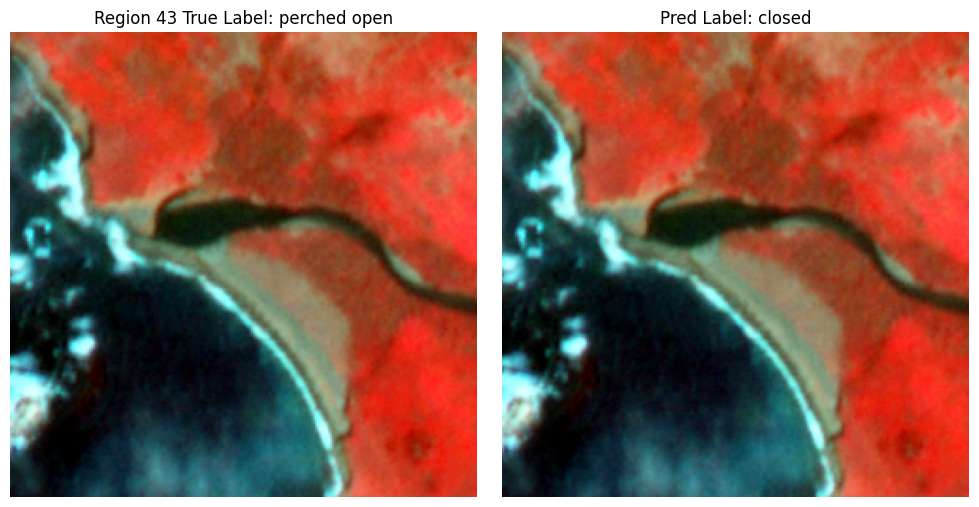

In [26]:
inspect_row(inspect_d_iter, "_water", "_img")

In [43]:
non_merged_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260224-123117/all_regions_timeseries_preds.csv"
)
len(non_merged_preds), (non_merged_preds.y_pred_unsure != 1).sum()

(101458, np.int64(96761))

In [51]:
train_preds = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260224-123117/train_preds.csv"
)
len(train_preds), (train_preds.y_pred_unsure != 1).sum().item()

(12689, 10223)

In [49]:
preds_all_orig = pd.read_csv(
    "/Users/kyledorman/data/results/estuary/train/20260224-123117/merged_all_regions_timeseries_preds.csv"
)

preds_all_orig["acquired"] = pd.to_datetime(preds_all_orig["acquired"], errors="coerce", utc=True)
preds_all_orig["date"] = preds_all_orig.acquired.dt.date
preds_all_orig["month"] = preds_all_orig.acquired.dt.month
preds_all_orig["year"] = preds_all_orig.acquired.dt.year
preds_all = preds_all_orig.copy()
preds_all = (
    preds_all[(preds_all.region.isin(gdf.index)) & (preds_all.y_pred_unsure != 1)]
    .copy()
    .sort_values(by=["region", "acquired"])
    .reset_index(drop=True)
)

preds_all.head(3)

,region,date,y_true,y_true_unsure,acquired,source_tif,y_pred_unsure,y_pred,openness,p_closed,p_perched_open,p_open,month,year
0,11,2017-02-01,1,0,2017-02-01 17:46:04+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.842874,0.078563,0.035938,0.885499,2,2017
1,11,2017-02-10,1,0,2017-02-10 17:45:58+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.766740,0.116630,0.007785,0.875585,2,2017
2,11,2017-02-25,1,0,2017-02-25 17:46:40+00:00,/Volumes/x10pro/estuary/sat_data/dove/results/...,0,2.0,0.999906,0.000047,0.000015,0.999938,2,2017


In [56]:
train_preds.y_true.value_counts()

y_true
 0    4988
 2    4149
-1    2599
 1     953
Name: count, dtype: int64

Val Accuracy 3 class 88.8
Val F1 3 class 86.3
Val Perched F1 71.2
Val Accuracy 2 class 96.4
Val F1 2 class 95.8
Test Accuracy 3 class 82.9
Test F1 3 class 80.5
Test Perched F1 57.6
Test Accuracy 2 class 95.2
Test F1 2 class 95.2


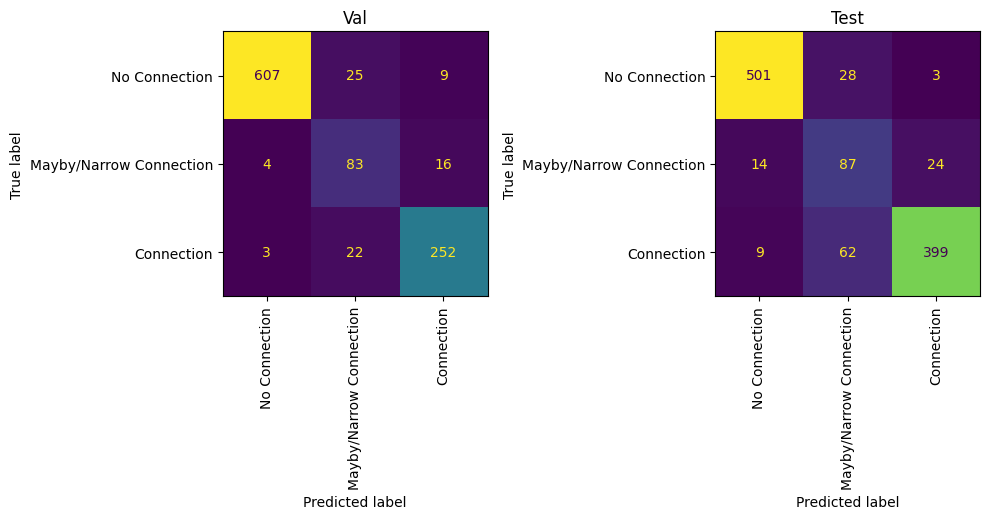

In [63]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

preds_21 = train_preds[(train_preds.year == 2021) & (train_preds.y_true >= 0)]
preds_25 = train_preds[(train_preds.year == 2025) & (train_preds.y_true >= 0)]

disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
y_true = preds_21.y_true
y_pred = preds_21.y_pred

print("Val Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Val F1 3 class", round(100 * f1_score(y_true, y_pred, average="macro"), 1))
print("Val Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=axes[0],
    colorbar=False,
    xticks_rotation="vertical",
)

axes[0].set_title("Val")

y_true = preds_21.y_true == 0
y_pred = preds_21.y_pred == 0

print("Val Accuracy 2 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Val F1 2 class", round(100 * f1_score(y_true, y_pred, average="macro"), 1))

y_true = preds_25.y_true
y_pred = preds_25.y_pred

print("Test Accuracy 3 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Test F1 3 class", round(100 * f1_score(y_true, y_pred, average="macro"), 1))
print("Test Perched F1", round(100 * f1_score(y_true == 1, y_pred == 1), 1))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=disp_labels,
    ax=axes[1],
    colorbar=False,
    xticks_rotation="vertical",
)

axes[1].set_title("Test")

y_true = preds_25.y_true == 0
y_pred = preds_25.y_pred == 0

print("Test Accuracy 2 class", round(100 * balanced_accuracy_score(y_true, y_pred), 1))
print("Test F1 2 class", round(100 * f1_score(y_true, y_pred, average="macro"), 1))

fig.tight_layout()
# fig.savefig("cm_open_closed_dove_water.png", dpi=300)
plt.show()

In [129]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

LABELS_3 = ["closed", "perched open", "open"]
LABELS_2 = ["not closed", "closed"]  # note: 0=not-closed, 1=closed in our mapping below


def _macro_f1_3(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", labels=[0, 1, 2], zero_division=1)


def _per_class_f1_3(y_true, y_pred):
    # returns array [f1_closed, f1_perched, f1_open]
    return f1_score(y_true, y_pred, average=None, labels=[0, 1, 2], zero_division=1)


def _to_closed_vs_not(y):
    # your definition: "closed" is class 0
    return (np.asarray(y) == 0).astype(int)  # 1=closed, 0=not-closed


def _macro_f1_2(y_true2, y_pred2):
    return f1_score(y_true2, y_pred2, average="macro", labels=[0, 1], zero_division=1)


def _per_class_f1_2(y_true2, y_pred2):
    # returns array [f1_not_closed, f1_closed]
    return f1_score(y_true2, y_pred2, average=None, labels=[0, 1], zero_division=1)


def summarize_split_3class(df: pd.DataFrame, split_name: str, region_col: str = "region") -> dict:
    df = df[(df["y_true"] >= 0) & (df["y_pred"] >= 0)].copy()
    y_true = df["y_true"].to_numpy()
    y_pred = df["y_pred"].to_numpy()

    f1_macro = _macro_f1_3(y_true, y_pred)
    f1_closed, f1_perched, f1_open = _per_class_f1_3(y_true, y_pred).tolist()

    # per-region macro F1 (3-class)
    per_region = (
        df.groupby(region_col)
        .apply(
            lambda g: _macro_f1_3(g["y_true"].to_numpy(), g["y_pred"].to_numpy()),
            include_groups=False,
        )
        .rename("f1_macro_3")
    )
    min_region = per_region.idxmin()
    min_region_f1 = float(per_region.loc[min_region])
    mean_region_f1 = float(per_region.mean())
    std_region_f1 = float(per_region.std())

    return {
        "split": split_name,
        "n": len(df),
        "f1": f1_macro,
        "f1_no_conn": f1_closed,
        "f1_maybe_conn": f1_perched,
        "f1_conn": f1_open,
        "min_region_f1": min_region_f1,
        "min_region": min_region,
        "mean_region_f1": mean_region_f1,
    }


def summarize_split_2class(df: pd.DataFrame, split_name: str, region_col: str = "region") -> dict:
    df = df[(df["y_true"] >= 0) & (df["y_pred"] >= 0)].copy()

    y_true2 = _to_closed_vs_not(df["y_true"].to_numpy())  # 1=closed, 0=not-closed
    y_pred2 = _to_closed_vs_not(df["y_pred"].to_numpy())

    f1_macro = _macro_f1_2(y_true2, y_pred2)
    f1_not_closed, f1_closed = _per_class_f1_2(y_true2, y_pred2).tolist()

    # per-region macro F1 (2-class)
    per_region = (
        df.assign(y_true2=y_true2, y_pred2=y_pred2)
        .groupby(region_col)
        .apply(
            lambda g: _macro_f1_2(g["y_true2"].to_numpy(), g["y_pred2"].to_numpy()),
            include_groups=False,
        )
        .rename("f1_macro_2")
    )
    min_region = per_region.idxmin()
    min_region_f1 = float(per_region.loc[min_region])
    mean_region_f1 = float(per_region.mean())
    std_region_f1 = float(per_region.std())

    return {
        "split": split_name,
        "n": len(df),
        "f1": f1_macro,
        "min_region_f1": min_region_f1,
        "min_region": min_region,
        "mean_region_f1": mean_region_f1,
    }


# ---- Build the two paper-ready tables ----
preds_val = train_preds[(train_preds.year == 2021) & (train_preds.y_true >= 0)]
preds_test = train_preds[(train_preds.year == 2025) & (train_preds.y_true >= 0)]
preds_train = train_preds[(~train_preds.year.isin([2025, 2021])) & (train_preds.y_true >= 0)]

table_3 = pd.DataFrame(
    [
        summarize_split_3class(preds_val, "val (2021)", region_col="region"),
        summarize_split_3class(preds_test, "test (2025)", region_col="region"),
        # summarize_split_3class(preds_train, "train", region_col="region"),
    ]
)

table_2 = pd.DataFrame(
    [
        summarize_split_2class(preds_val, "val (2021)", region_col="region"),
        summarize_split_2class(preds_test, "test (2025)", region_col="region"),
        # summarize_split_2class(preds_train, "train", region_col="region"),
    ]
)


# Optional: convert F1 columns to percent for paper tables
def to_percent_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for c in out.columns:
        if c.startswith("f1_") and out[c].dtype != object:
            out[c] = (100.0 * out[c]).round(1)
    return out


table_3_pct = to_percent_table(table_3)
table_2_pct = to_percent_table(table_2)

display(table_3_pct.round(2))
display(table_2_pct.round(2))

,split,n,f1,f1_no_conn,f1_maybe_conn,f1_conn,min_region_f1,min_region,mean_region_f1
0,val (2021),1021,0.86,96.7,71.2,91.0,0.13,13028,0.84
1,test (2025),1127,0.81,94.9,57.6,89.1,0.31,21,0.77


,split,n,f1,min_region_f1,min_region,mean_region_f1
0,val (2021),1021,0.96,0.32,13028,0.92
1,test (2025),1127,0.95,0.47,2147,0.92


In [131]:
import matplotlib.pyplot as plt


def save_table_png(df: pd.DataFrame, path: str, title: str = None):
    fig, ax = plt.subplots(figsize=(1.6 * len(df.columns), 1 + 0.5 * len(df)))
    ax.axis("off")

    if title:
        ax.set_title(title, fontsize=14, pad=12)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    # Bold header row
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")

    fig.tight_layout()
    fig.savefig(path, dpi=300, bbox_inches="tight")
    plt.close(fig)

In [136]:
table_3_fmt = table_3_pct.rename(
    columns={
        "split": "Split",
        "n": "N",
        "f1": "F1 (3-Class)",
        "f1_no_conn": "F1: No Connection",
        "f1_maybe_conn": "F1: Narrow/Perched",
        "f1_conn": "F1: Connection",
        "min_region_f1": "Worst Region F1",
        "mean_region_f1": "Mean Region F1",
    }
).drop(columns=["min_region"])

save_table_png(table_3_fmt.round(2), SAVE_DIR / "results_3class.png", title="3-Class Results")

In [137]:
table_2_fmt = table_2_pct.rename(
    columns={
        "split": "Split",
        "n": "N",
        "f1": "F1 (2-Class)",
        "min_region_f1": "Worst Region F1",
        "mean_region_f1": "Mean Region F1",
    }
).drop(columns=["min_region"])

save_table_png(table_2_fmt.round(2), SAVE_DIR / "results_2class.png", title="2-Class Results")

In [139]:
import numpy as np
import pandas as pd

disp_labels = ["No Connection", "Mayby/Narrow Connection", "Connection"]
all_classes = ["Low Quality"] + disp_labels


def summarize_dataset(df: pd.DataFrame, name: str) -> dict:
    df = df.copy()

    # Map predictions to display label
    df["label"] = np.where(
        df["y_pred_unsure"], "Low Quality", df["y_pred"].map(dict(enumerate(disp_labels)))
    )

    total = len(df)
    counts = df["label"].value_counts().reindex(all_classes, fill_value=0)

    row = {"Dataset": name, "N": total}

    for cls in all_classes:
        c = counts[cls]
        pct = 100 * c / total if total > 0 else 0
        # row[f"{cls} (n)"] = c
        row[f"{cls} (%)"] = round(pct, 1)

    return row


table = pd.DataFrame(
    [
        summarize_dataset(non_merged_preds, "All Predictions"),
        summarize_dataset(preds_all_orig, "Merged Same-Day"),
    ]
)

table

,Dataset,N,Low Quality (%),No Connection (%),Mayby/Narrow Connection (%),Connection (%)
0,All Predictions,101458,4.6,49.6,12.5,33.2
1,Merged Same-Day,76621,5.2,49.0,12.3,33.5
